# Data (from week 1) needed for our week 2 response
## Import

In [1]:
import xarray as xr
import pandas as pd
import rasterio
from rasterio.mask import mask
from rasterio.transform import from_bounds
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
import seaborn as sns
import scipy
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, Concatenate, Embedding, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import statsmodels.api as sm
import scipy.stats as stats
from tqdm import tqdm
import os


## 1. Useful datas for final week

## 2. Our answer for this last week



Objective : *summarize our findings and propose explanatory models or adjustments to existing data.*

In [19]:
all_data_list = []
stations_list = [c for c in stations_df.columns if 'Mean' not in str(c)]

for staid in stations_list:
    if staid not in ndvi_stations_df.columns: continue
    
    temp_station = stations_df['Mean_stations']
    era5_for_station = era5_timed_series_by_stations[staid]
    ndvi_for_station = ndvi_stations_df[staid]
    ndvi_daily = ndvi_for_station.reindex(temp_station.index, method='ffill')

    df_temp = pd.DataFrame({
        'Date': temp_station.index,
        'Station_ID': staid,
        'Station_TX': temp_station.values,
        'ERA5_TX': era5_for_station.reindex(temp_station.index).values,
        'NDVI': ndvi_daily.values
    })
    all_data_list.append(df_temp)

df_final = pd.concat(all_data_list, ignore_index=False)
df_final['Month'] = df_final['Date'].dt.month


df_final['Season'] = df_final['Month'].apply(get_season)
df_final['Error'] = df_final['Station_TX']-df_final['ERA5_TX']
df_sim = df_final.dropna()
df_simulation = df_sim.set_index('Date')
print(df_sim)

           Date  Station_ID  Station_TX    ERA5_TX      NDVI  Month  Season  \
506  2020-03-01         230   14.071429  12.287079  0.590551      3  Spring   
507  2020-03-02         230   11.904762  11.518280  0.590551      3  Spring   
508  2020-03-03         230   14.361905  15.338837  0.590551      3  Spring   
509  2020-03-04         230   16.785714  17.218597  0.590551      3  Spring   
510  2020-03-05         230   14.276190  15.493073  0.590551      3  Spring   
...         ...         ...         ...        ...       ...    ...     ...   
1204 2025-07-26       27245   32.561905  31.530304  0.425197      7  Autumn   
1205 2025-07-27       27245   35.061905  34.282593  0.425197      7  Autumn   
1206 2025-07-28       27245   32.638095  31.609039  0.425197      7  Autumn   
1207 2025-07-29       27245   31.261905  30.368134  0.425197      7  Autumn   
1208 2025-07-30       27245   32.923810  31.131897  0.425197      7  Autumn   

         Error  
506   1.784350  
507   0.386482  


## First method : multivariate linear regression

In [20]:
all_errors = []

for staid in staids:
    if staid in discreptancies_by_stations.columns:
        temp_df = pd.DataFrame({
            'Error': discreptancies_by_stations[staid],
            'Station': staid,
            'Date': discreptancies_by_stations.index
        })
        if staid in ndvi_stations_df.columns:
            ndvi_aligned = ndvi_stations_df[staid].reindex(temp_df['Date'], method='ffill')
            temp_df['NDVI'] = ndvi_aligned
        
        all_errors.append(temp_df)

df_analysis = pd.concat(all_errors)
df_analysis['Month'] = df_analysis['Date'].dt.month

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df_analysis['Season'] = df_analysis['Month'].apply(get_season)


seasonal_metrics = df_analysis.groupby('Season')['Error'].agg(['mean', 'std', 'count'])
seasonal_metrics['RMSE'] = df_analysis.groupby('Season')['Error'].apply(lambda x: (x**2).mean())
seasonal_metrics.columns = ['Bias (Mean Error)', 'STD', 'Count', 'MSE']

print("Metrics by season :")
print(seasonal_metrics)

Metrics by season :
        Bias (Mean Error)       STD  Count       MSE
Season                                              
Autumn           1.290991  1.832764   2646  5.024414
Spring           1.342403  1.774480   3654  4.949962
Summer           1.636627  1.686621   4137  5.522552
Winter           1.384722  1.964073   5082  5.774281


             Bias      RMSE  Mean_NDVI  HGHT        Lat       Lon
Station                                                          
230      0.294517  1.166791   0.535713   667  40.411667 -3.678056
3839     1.904889  2.271932   0.531345   607  40.488333 -3.443333
3945     0.195731  1.251105   0.103135  1004  40.695833 -3.765000
3946     1.893727  2.270107   0.512875   609  40.466667 -3.555556
3947     1.112443  1.574714   0.133925   690  40.375556 -3.785833


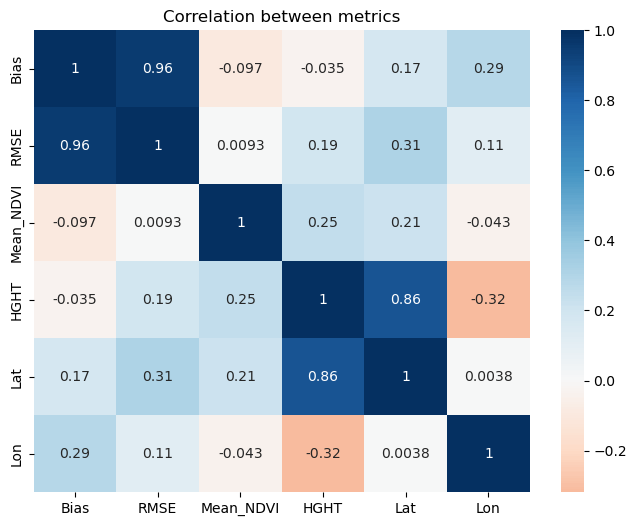

C:\Users\moham\AppData\Local\Temp\ipykernel_120480\1707501269.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sim['Date'] = pd.to_datetime(df_sim['Date'])
C:\Users\moham\AppData\Local\Temp\ipykernel_120480\1707501269.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sim['Month'] = df_sim['Date'].dt.month
C:\Users\moham\AppData\Local\Temp\ipykernel_120480\1707501269.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_


Les premières lignes de la série temporelle prédite sont :
Date
2020-03-01    13.120914
2020-03-02    11.355596
2020-03-03    14.955230
2020-03-04    16.764928
2020-03-05    15.005012
Name: Predicted Mean Station TX (Corrected ERA5), dtype: float64

RÉSUMÉ DES RÉSULTATS DE LA RÉGRESSION LINÉAIRE (OLS):
                            OLS Regression Results                            
Dep. Variable:                  Error   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     40.80
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           5.76e-22
Time:                        00:48:11   Log-Likelihood:                -115.63
No. Observations:                  84   AIC:                             245.3
Df Residuals:                      77   BIC:                             262.3
Df Model:                           6                          

In [21]:
station_meta = stations_gdf[['STAID', 'HGHT']].set_index('STAID')

station_meta['Lat'] = stations_gdf.geometry.y.values
station_meta['Lon'] = stations_gdf.geometry.x.values

station_perf = df_analysis.groupby('Station').agg({
    'Error': ['mean', lambda x: np.sqrt((x**2).mean())], # Bias et RMSE
    'NDVI': 'mean' # NDVI moyen sur la période
})
station_perf.columns = ['Bias', 'RMSE', 'Mean_NDVI']
explanatory_df = station_perf.join(station_meta)
print(explanatory_df.head())

plt.figure(figsize=(8, 6))
sns.heatmap(explanatory_df.corr(), annot=True, cmap='RdBu', center=0)
plt.title("Correlation between metrics")
plt.show()
df_sim['Date'] = pd.to_datetime(df_sim['Date']) 
df_sim['Month'] = df_sim['Date'].dt.month

def get_season(month):
    if 1<=month<=3: return 'Spring'
    elif 4<=month<=6: return 'Summer'
    elif 7<=month<=9: return 'Autumn'
    else: return 'Winter'

df_sim['Season'] = df_sim['Month'].apply(get_season)

# Joindre les métadonnées (Lon, Lat) au DataFrame journalier
# station_meta est supposé être un DataFrame indexé par STAID (int)
df_model_daily = df_sim.merge(
    station_meta[['Lon', 'Lat']].astype(float),
    left_on='Station_ID',
    right_index=True
)
df_model_daily.rename(columns={'Lon': 'Longitude', 'Lat': 'Latitude'}, inplace=True)

# Créer le DataFrame agrégé par station/saison (pour le FIT du modèle)
data_to_model = df_model_daily.groupby(['Station_ID', 'Season']).agg({
    'Error': 'mean',
    'NDVI': 'mean',
    'Longitude': 'first',
    'Latitude': 'first'
}).reset_index()

# --- 3. DÉFINITION DES VARIABLES OLS ---

dummy_seasons = pd.get_dummies(data_to_model['Season'], drop_first=False, prefix='Season')
dummy_seasons = dummy_seasons.drop(columns=['Season_Spring'])
data_model_final = pd.concat([data_to_model, dummy_seasons], axis=1)

Y = data_model_final['Error'].astype(float)
# X inclut NDVI, Longitude, Latitude et les dummies saisonnières (Spring est la référence)
X = data_model_final[['NDVI', 'Longitude', 'Latitude', 'Season_Summer', 'Season_Autumn', 'Season_Winter']]

X = X.astype(float)
X = sm.add_constant(X)
X = X.fillna(X.mean())
Y = Y.fillna(Y.mean())

# --- 4. EXÉCUTION DE LA RÉGRESSION OLS ET PRÉDICTION ---

model = sm.OLS(Y, X).fit()

# 1. Calculer le biais moyen prédit pour chaque groupe Station/Saison (y_pred)
data_model_final['Bias_Predicted'] = model.fittedvalues

# 2. Créer le dictionnaire de mappage (Station_ID, Season) -> Bias_Predicted
bias_map = data_model_final.set_index(['Station_ID', 'Season'])['Bias_Predicted'].to_dict()

# 3. Mapper le biais prédit sur les données journalières
df_prediction_daily = df_model_daily.copy()
df_prediction_daily['Key'] = list(zip(df_prediction_daily['Station_ID'], df_prediction_daily['Season']))
df_prediction_daily['Predicted_Mean_Bias'] = df_prediction_daily['Key'].map(bias_map)

# 4. Calculer la TEMPÉRATURE PRÉDITE DE LA STATION
# Station_TX_Predicted = ERA5_TX_Original + Predicted_Mean_Bias
df_prediction_daily['Station_TX_Predicted'] = df_prediction_daily['ERA5_TX'] + df_prediction_daily['Predicted_Mean_Bias']

# 5. Calculer la SÉRIE TEMPORELLE FINALE (Moyenne journalière des prédictions)
final_predicted_time_series = df_prediction_daily.groupby('Date')['Station_TX_Predicted'].mean().rename('Predicted Mean Station TX (Corrected ERA5)')

print("\nLes premières lignes de la série temporelle prédite sont :")
print(final_predicted_time_series.head())
print("\n" + "="*50)
print("RÉSUMÉ DES RÉSULTATS DE LA RÉGRESSION LINÉAIRE (OLS):")
print("="*50)
print(model.summary())

In [22]:
# --- PLOTTING LOGIC (Using corrected aggregation) ---

# 1. Predicted Mean Bias (y_pred is model.fittedvalues)
data_model_final['Bias_Predicted'] = model.fittedvalues

# 2. Create the mapping dictionary (Station_ID, Season) -> Bias_Predicted
bias_map = data_model_final.set_index(['Station_ID', 'Season'])['Bias_Predicted'].to_dict()

# 3. Map the predicted mean bias back to the daily data (df_model_daily)
df_prediction_daily = df_model_daily.copy()
df_prediction_daily['Key'] = list(zip(df_prediction_daily['Station_ID'], df_prediction_daily['Season']))
df_prediction_daily['Predicted_Mean_Bias'] = df_prediction_daily['Key'].map(bias_map)

# 4. Calculate the Predicted Station TX (Corrected ERA5 TX)
df_prediction_daily['Station_TX_Predicted'] = df_prediction_daily['ERA5_TX'] + df_prediction_daily['Predicted_Mean_Bias']

# 5. Calculate the Final Predicted Time Series (daily average across all stations)
final_predicted_time_series = df_prediction_daily.groupby('Date')['Station_TX_Predicted'].mean().rename('Corrected ERA5 (OLS Model)')

# 6. Calculate the daily means for the reference series
actual_mean_station_tx = df_prediction_daily.groupby('Date')['Station_TX'].mean().rename('Reality (Station)')
original_mean_era5_tx = df_prediction_daily.groupby('Date')['ERA5_TX'].mean().rename('Original ERA5 (Before)')

# 7. Combine all three series for plotting and limit to 200 days
df_comparison_plot = pd.DataFrame({
    'Reality (Station)': actual_mean_station_tx,
    'Original ERA5 (Before)': original_mean_era5_tx,
    'Corrected ERA5 (OLS Model)': final_predicted_time_series
}).dropna()

num_days = 365
df_plot_subset = df_comparison_plot.head(num_days)



RMSE : 0.9259572905704451
MAE = 0.6966003862820939
Bias = 1.5791382742292838e-13


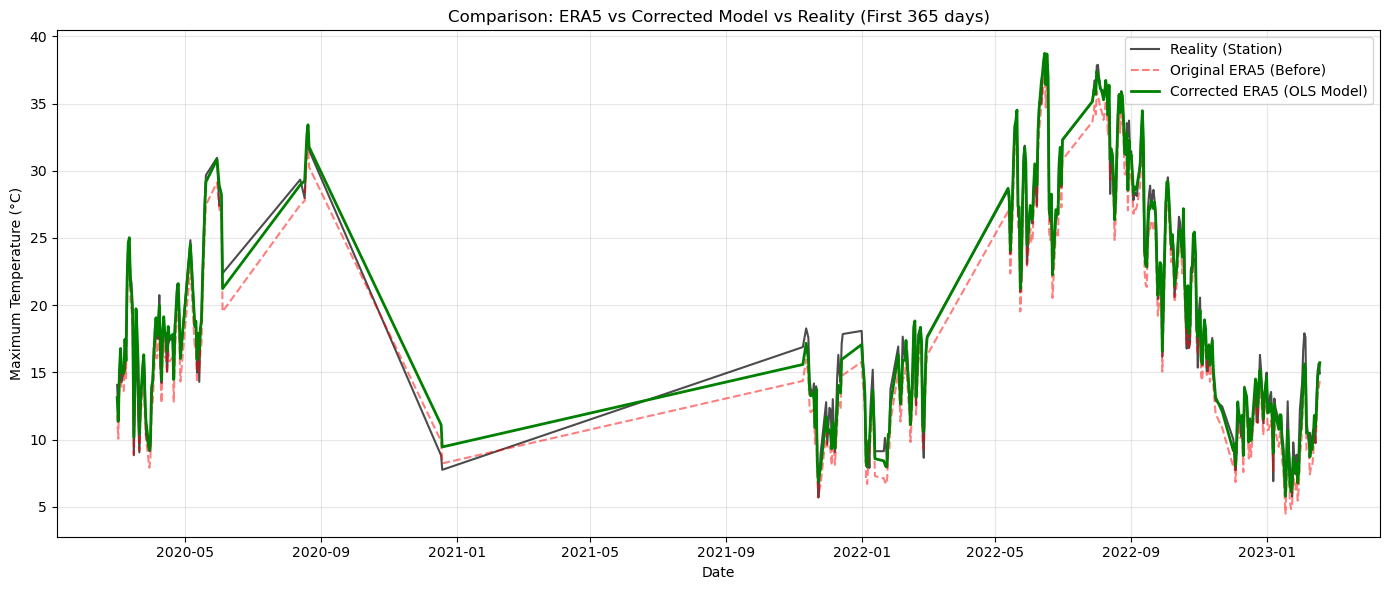

In [23]:
# 8. Generate the plot
plt.figure(figsize=(14, 6))
plt.plot(df_plot_subset.index, df_plot_subset['Reality (Station)'], 
         label='Reality (Station)', color='black', alpha=0.7)
plt.plot(df_plot_subset.index, df_plot_subset['Original ERA5 (Before)'], 
         label='Original ERA5 (Before)', color='red', linestyle='--', alpha=0.5)
plt.plot(df_plot_subset.index, df_plot_subset['Corrected ERA5 (OLS Model)'], 
         label='Corrected ERA5 (OLS Model)', color='green', linewidth=2)

# Affichage des résultats
plt.title(f'Comparison: ERA5 vs Corrected Model vs Reality (First {len(df_plot_subset)} days)')
plt.ylabel('Maximum Temperature (°C)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

print(f"RMSE : {np.sqrt(np.mean((df_comparison_plot['Reality (Station)']-df_comparison_plot['Corrected ERA5 (OLS Model)'])**2))}")
mae = np.mean(abs(df_comparison_plot['Reality (Station)']-df_comparison_plot['Corrected ERA5 (OLS Model)']))
bias = np.mean(df_comparison_plot['Reality (Station)']-df_comparison_plot['Corrected ERA5 (OLS Model)'])

print(f"MAE = {mae}")
print(f"Bias = {bias}")

## Second method : using RandomForest

In [24]:
df_final['Month_Num'] = df_final['Date'].dt.month

df_final['Month_Sin'] = np.sin(2 * np.pi * df_final['Month_Num']/12)
df_final['Month_Cos'] = np.cos(2 * np.pi * df_final['Month_Num']/12)

def get_season(month):
    if month in [1, 2,3]: return 'Winter'
    elif month in [4, 5, 6]: return 'Spring'
    elif month in [7, 8, 9]: return 'Summer'
    else: return 'Autumn'

df_final['Season'] = df_final['Month_Num'].apply(get_season)

df_model = df_final.dropna().copy()

features = ['ERA5_TX', 'NDVI', 'Month_Sin', 'Month_Cos']
target = 'Station_TX'

rf_global = RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42)
rf_global.fit(df_model[features], df_model[target])

df_model['Corrected_TX'] = rf_global.predict(df_model[features])

# Calcul des erreurs
df_model['Error_ERA5'] = df_model['Station_TX'] - df_model['ERA5_TX']
df_model['Error_Corrected'] = df_model['Station_TX'] - df_model['Corrected_TX']



In [25]:
seasonal_stats = df_model.groupby('Season').apply(
    lambda x: pd.Series({
        'RMSE_ERA5': np.sqrt(mean_squared_error(x['Station_TX'], x['ERA5_TX'])),
        'RMSE_Corrected': np.sqrt(mean_squared_error(x['Station_TX'], x['Corrected_TX'])),
        'Count': len(x)
    })
).reset_index()

seasonal_stats['Gain'] = seasonal_stats['RMSE_ERA5'] - seasonal_stats['RMSE_Corrected']


plt.figure(figsize=(12, 6))

# Ordre des saisons pour l'affichage
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
df_model['Season'] = pd.Categorical(df_model['Season'], categories=season_order, ordered=True)
print(df_model.head())


          Date  Station_ID  Station_TX    ERA5_TX      NDVI  Month  Season  \
506 2020-03-01         230   14.071429  12.287079  0.590551      3  Winter   
507 2020-03-02         230   11.904762  11.518280  0.590551      3  Winter   
508 2020-03-03         230   14.361905  15.338837  0.590551      3  Winter   
509 2020-03-04         230   16.785714  17.218597  0.590551      3  Winter   
510 2020-03-05         230   14.276190  15.493073  0.590551      3  Winter   

        Error  Month_Num  Month_Sin     Month_Cos  Corrected_TX  Error_ERA5  \
506  1.784350          3        1.0  6.123234e-17     13.379857    1.784350   
507  0.386482          3        1.0  6.123234e-17     12.983857    0.386482   
508 -0.976932          3        1.0  6.123234e-17     16.109271   -0.976932   
509 -0.432883          3        1.0  6.123234e-17     17.766411   -0.432883   
510 -1.216882          3        1.0  6.123234e-17     16.152038   -1.216882   

     Error_Corrected  
506         0.691572  
507       

C:\Users\moham\AppData\Local\Temp\ipykernel_120480\3539169452.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  seasonal_stats = df_model.groupby('Season').apply(


<Figure size 1200x600 with 0 Axes>

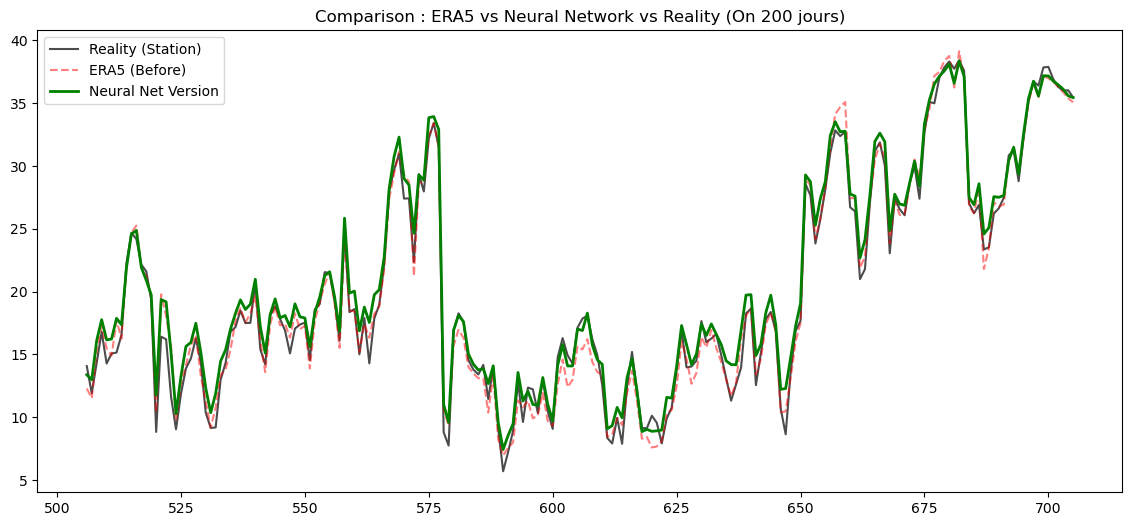

RMSE : 1.0756840801669827
MAE = 0.796614502154853
Bias = 0.002036890744983005


In [26]:
num_days=200
plt.figure(figsize=(14, 6))
plt.plot(df_model['Station_TX'][:num_days], label='Reality (Station)', color='black', alpha=0.7)
plt.plot(df_model['ERA5_TX'][:num_days], label='ERA5 (Before)', color='red', linestyle='--', alpha=0.5)
plt.plot(df_model['Corrected_TX'][:num_days], label='Neural Net Version', color='green', linewidth=2)
plt.title(f'Comparison : ERA5 vs Neural Network vs Reality (On {num_days} jours)')
plt.legend()
plt.show()

print(f"RMSE : {np.sqrt(np.mean((df_model['Station_TX']-df_model['Corrected_TX'])**2))}")
mae=np.mean(abs(df_model['Station_TX']-df_model['Corrected_TX']))
bias = np.mean(df_model['Station_TX']-df_model['Corrected_TX'])
print(f"MAE = {mae}")
print(f"Bias = {bias}")

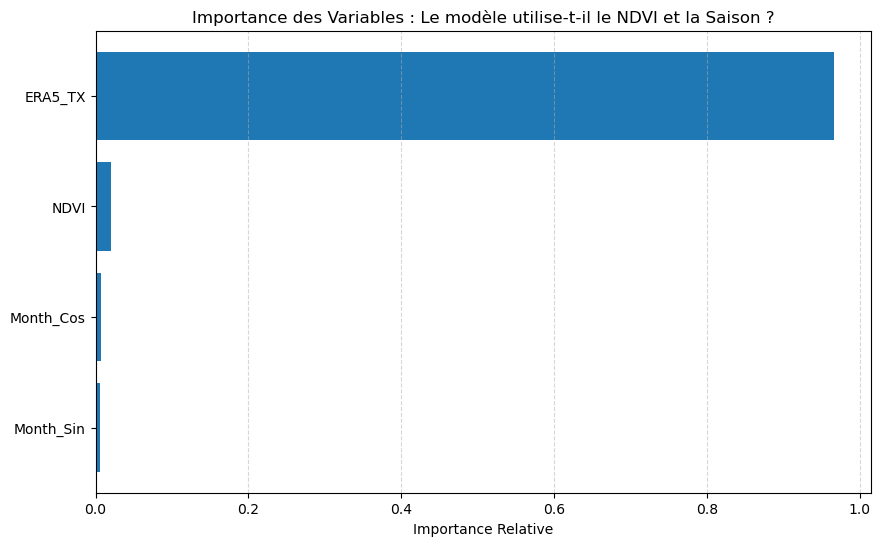

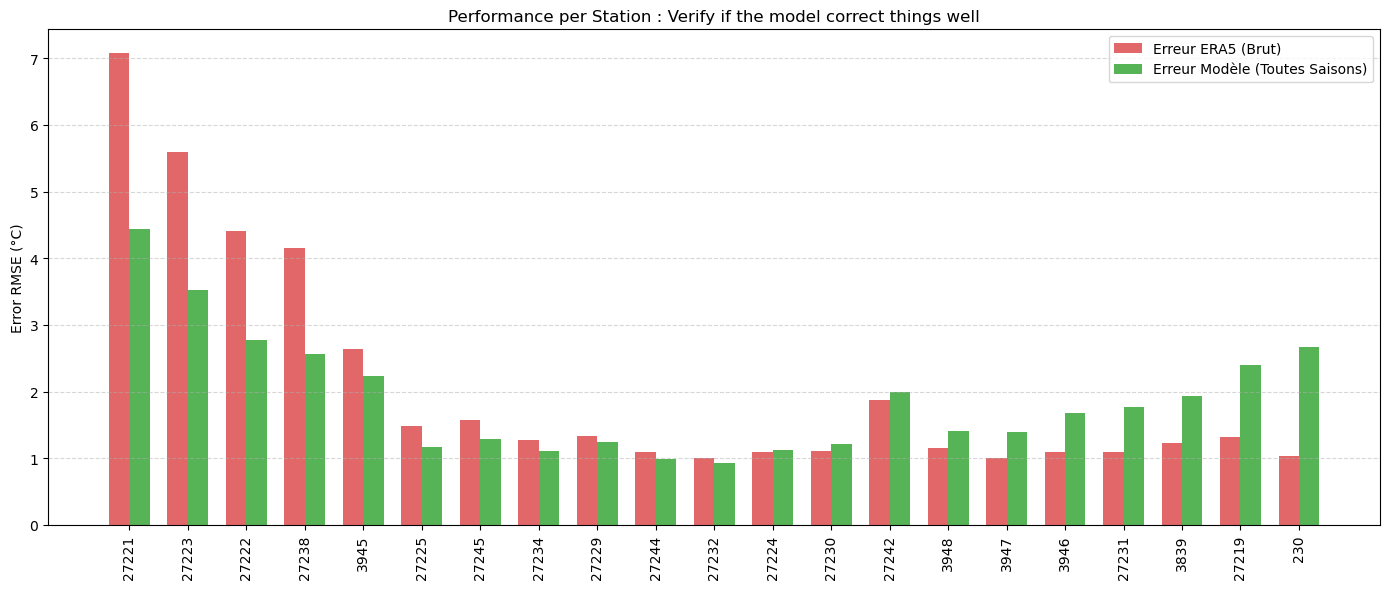

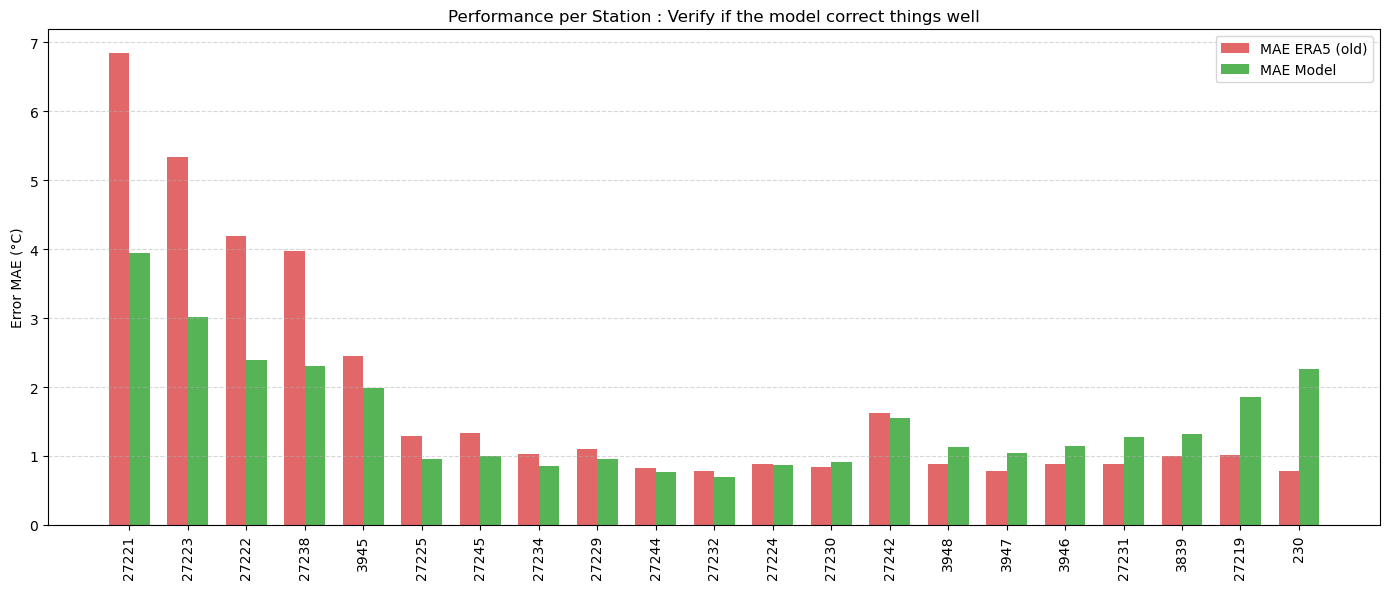

1.5360193422488204


In [27]:
importances = rf_global.feature_importances_
feature_names = ['ERA5_TX', 'NDVI', 'Month_Sin', 'Month_Cos']
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Importance des Variables : Le modèle utilise-t-il le NDVI et la Saison ?')
plt.barh(range(len(indices)), importances[indices], color='#1f77b4', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importance Relative')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

results_cv_season = []
features_season = ['ERA5_TX', 'NDVI', 'Month_Sin', 'Month_Cos']
stations_list = df_model['Station_ID'].unique()

for test_station in stations_list:
    # Séparation
    train_data = df_model[df_model['Station_ID'] != test_station]
    test_data = df_model[df_model['Station_ID'] == test_station]
    
    if len(test_data) == 0: continue

    # Entraînement temporaire
    model_cv = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
    model_cv.fit(train_data[features_season], train_data['Station_TX'])
    
    # Prédiction
    pred_cv = model_cv.predict(test_data[features_season])
    
    # Scores
    rmse_era5 = np.sqrt(mean_squared_error(test_data['Station_TX'], test_data['ERA5_TX']))
    rmse_model = np.sqrt(mean_squared_error(test_data['Station_TX'], pred_cv))
    mae_era = np.mean(abs((test_data['Station_TX']- test_data['ERA5_TX'])))
    mae = np.mean(abs((test_data['Station_TX']- pred_cv)))
    
    results_cv_season.append({
        'Station': test_station,
        'RMSE_ERA5': rmse_era5,
        'RMSE_Corrected': rmse_model,
        'Gain': rmse_era5 - rmse_model,
        'MAE ERA5 (old)': mae_era,
        'New MAE' : mae
    })

df_res_season = pd.DataFrame(results_cv_season).sort_values('Gain', ascending=False)

# Tracé du graphique
plt.figure(figsize=(14, 6))
x = np.arange(len(df_res_season))
width = 0.35

plt.bar(x - width/2, df_res_season['RMSE_ERA5'], width, label='Erreur ERA5 (Brut)', color='#d62728', alpha=0.7)
plt.bar(x + width/2, df_res_season['RMSE_Corrected'], width, label='Erreur Modèle (Toutes Saisons)', color='#2ca02c', alpha=0.8)

plt.xticks(x, df_res_season['Station'], rotation=90)
plt.ylabel('Error RMSE (°C)')
plt.title('Performance per Station : Verify if the model correct things well')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
x = np.arange(len(df_res_season))
width = 0.35

plt.bar(x - width/2, df_res_season['MAE ERA5 (old)'], width, label='MAE ERA5 (old)', color='#d62728', alpha=0.7)
plt.bar(x + width/2, df_res_season['New MAE'], width, label='MAE Model', color='#2ca02c', alpha=0.8)

plt.xticks(x, df_res_season['Station'], rotation=90)
plt.ylabel('Error MAE (°C)')
plt.title('Performance per Station : Verify if the model correct things well')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
m=df_res_season['New MAE'].mean()
print(m)

## Third method : Neural Network

In [28]:
# Setuping the datas
features = ['ERA5_TX', 'NDVI', 'Month_Sin', 'Month_Cos']
target = 'Station_TX'

# Nettoyage
df_nn = df_final.dropna().copy()

X = df_nn[features].values
y = df_nn[target].values

print(df_nn['ERA5_TX'])

506     12.287079
507     11.518280
508     15.338837
509     17.218597
510     15.493073
          ...    
1204    31.530304
1205    34.282593
1206    31.609039
1207    30.368134
1208    31.131897
Name: ERA5_TX, Length: 14763, dtype: float32


In [29]:
# Setuping the datas
features = ['ERA5_TX', 'NDVI', 'Month_Sin', 'Month_Cos']
target = 'Station_TX'

# Nettoyage
df_nn = df_final.dropna().copy()

X = df_nn[features].values
y = df_nn[target].values

In [30]:
from tqdm import tqdm
import os

# ==========================================
# 1. SELECTION DE TOUTES LES STATIONS (ESPAGNE)
# ==========================================

print("Chargement de la carte et des stations...")
# Géométrie de l'Espagne
spain_gdf = gadm_gdf[(gadm_gdf.GID_0 == "ESP")& (gadm_gdf.NAME_2 != "Madrid")].dissolve()

# Chargement du fichier de métadonnées des stations
stations_df = pd.read_csv(stations_filepath, skiprows=17, skipinitialspace=True)
stations_df['LAT_decimal'] = stations_df['LAT'].apply(dms_to_decimal)
stations_df['LON_decimal'] = stations_df['LON'].apply(dms_to_decimal)

stations_gdf = gpd.GeoDataFrame(
    stations_df,
    geometry=gpd.points_from_xy(stations_df['LON_decimal'], stations_df['LAT_decimal']),
    crs="EPSG:4326"
)

# Filtre : on ne garde que les stations qui sont en Espagne
stations_in_spain = stations_gdf[stations_gdf.within(spain_gdf.geometry.iloc[0])]
print(f"Stations trouvées en Espagne : {len(stations_in_spain)}")

# ==========================================
# 2. CREATION DU DATASET MASSIF (X, y)
# ==========================================

X_list = []
y_list = []

# Période d'étude (à adapter selon vos fichiers ERA5 disponibles)
start_date = pd.Timestamp("2020-01-01")
end_date = pd.Timestamp("2023-12-31")

print("Construction du dataset d'entraînement...")

for idx, station in tqdm(stations_in_spain.iterrows(), total=len(stations_in_spain)):
    try:
        # A. Charger la donnée Station (Vérité Terrain)
        staid = station['STAID']
        fpath = eca_tx_datafolder + f"TX_STAID{staid:06d}.txt"
        
        if not os.path.exists(fpath): continue
            
        df_s = pd.read_csv(fpath, skiprows=20, skipinitialspace=True)
        # On ne garde que les données valides (Q_TX = 0)
        df_s = df_s[df_s['Q_TX'] == 0]
        df_s['DATE'] = pd.to_datetime(df_s['DATE'], format='%Y%m%d')
        df_s = df_s.set_index('DATE').sort_index()
        
        # Filtrer sur la période commune
        mask_date = (df_s.index >= start_date) & (df_s.index <= end_date)
        df_s = df_s.loc[mask_date]
        
        if len(df_s) < 50: continue # On ignore les stations avec trop peu de données
        
        station_series = df_s['TX'] / 10.0 # Conversion en °C
        station_series.name = 'Station_TX'
        
        # B. Extraire la donnée ERA5 (Input du modèle)
        # On utilise les coordonnées de la station pour chercher le point ERA5 le plus proche
        lat_s, lon_s = station.geometry.y, station.geometry.x
        
        # Selection 'nearest' dans le dataset xarray
        era5_point = ds[datavar].sel(latitude=lat_s, longitude=lon_s, method="nearest")
        era5_series = era5_point.to_series() - 273.15 # Kelvin -> Celsius
        era5_series.name = 'ERA5_TX'
        
        # C. Fusionner et nettoyer (drop NaN)
        # On ne garde que les jours où on a les DEUX infos (Station ET ERA5)
        merged = pd.concat([station_series, era5_series], axis=1).dropna()
        
        if len(merged) == 0: continue

        # Ajout aux listes
        X_list.append(merged[['ERA5_TX']].values)
        y_list.append(merged[['Station_TX']].values)
        
    except Exception as e:
        continue

# Assemblage final
if len(X_list) > 0:
    X_all = np.vstack(X_list)
    y_all = np.vstack(y_list)
    print(f"\nDataset prêt : {X_all.shape[0]} points de données (jours * stations).")
else:
    print("Erreur : Aucun dataset n'a pu être créé. Vérifiez vos chemins et dates.")

# ==========================================
# 3. RESEAU DE NEURONES (DEEP LEARNING)
# ==========================================

if len(X_list) > 0:
    # Split Train/Test
    X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

    # Standardisation (Essentiel pour les réseaux de neurones)
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    # Architecture du modèle
    # Plus profond que le précédent pour capturer les nuances de toutes les stations
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        BatchNormalization(), # Stabilise l'apprentissage
        Dropout(0.1),         # Evite le sur-apprentissage
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dense(32, activation='relu'),
        Dense(1)              # Sortie : Température corrigée
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Callbacks
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

    print("Démarrage de l'entraînement...")
    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=4096, # Grand batch size pour aller vite sur beaucoup de data
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # Evaluation
    loss, mae = model.evaluate(X_test_scaled, y_test)
    print(f"\nPerformance finale sur le Test Set - MAE: {mae:.4f} °C")

    

Chargement de la carte et des stations...
Stations trouvées en Espagne : 900
Construction du dataset d'entraînement...


100%|██████████| 900/900 [02:12<00:00,  6.80it/s]



Dataset prêt : 1143198 points de données (jours * stations).


Démarrage de l'entraînement...
Epoch 1/100


179/179 [==============================] - 5s 7ms/step - loss: 149.2020 - mae: 9.6154 - val_loss: 154.9891 - val_mae: 11.2052 - lr: 0.0010
Epoch 2/100
179/179 [==============================] - 1s 6ms/step - loss: 7.8788 - mae: 2.1235 - val_loss: 114.4134 - val_mae: 9.5275 - lr: 0.0010
Epoch 3/100
179/179 [==============================] - 1s 6ms/step - loss: 6.7568 - mae: 1.9420 - val_loss: 30.3280 - val_mae: 4.7301 - lr: 0.0010
Epoch 4/100
179/179 [==============================] - 1s 6ms/step - loss: 6.4556 - mae: 1.8872 - val_loss: 7.6145 - val_mae: 2.1255 - lr: 0.0010
Epoch 5/100
179/179 [==============================] - 1s 6ms/step - loss: 6.2782 - mae: 1.8533 - val_loss: 6.1338 - val_mae: 1.8272 - lr: 0.0010
Epoch 6/100
179/179 [==============================] - 1s 6ms/step - loss: 6.1447 - mae: 1.8277 - val_loss: 5.8330 - val_mae: 1.7652 - lr: 0.0010
Epoch 7/100
179/179

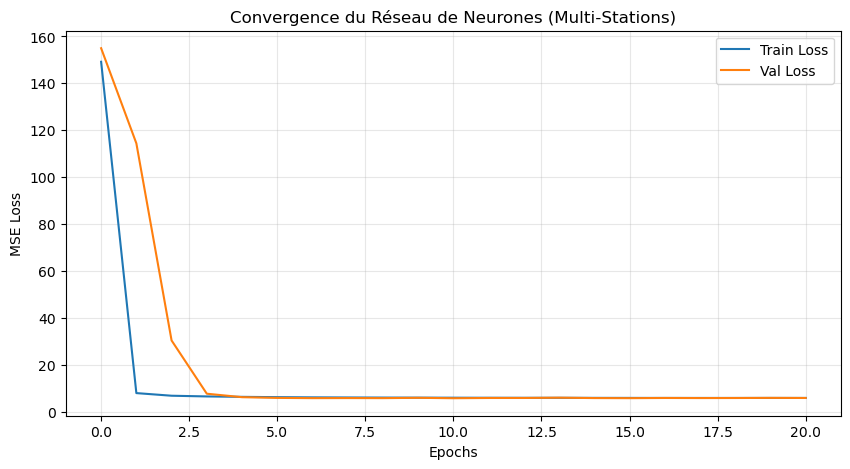

4/4 [==============================] - 0s 1ms/step


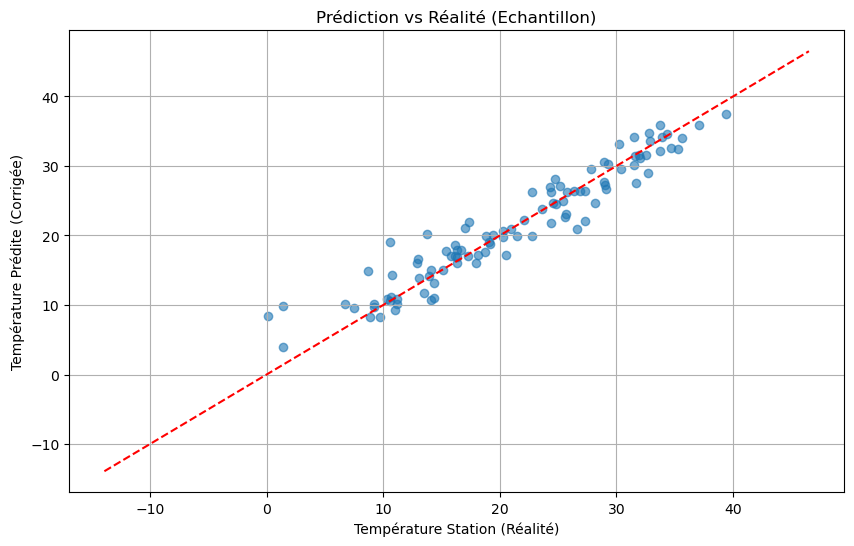

In [31]:
# Visualisation de la Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Convergence du Réseau de Neurones (Multi-Stations)")
plt.ylabel("MSE Loss")
plt.xlabel("Epochs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Visualisation Prédiction vs Réalité (sur un sous-échantillon pour lisibilité)
plt.figure(figsize=(10, 6))
subset_n = 100
plt.scatter(y_test[:subset_n], model.predict(X_test_scaled[:subset_n]), alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Ligne parfaite
plt.xlabel("Température Station (Réalité)")
plt.ylabel("Température Prédite (Corrigée)")
plt.title("Prédiction vs Réalité (Echantillon)")
plt.grid()
plt.show()

In [32]:
print(stations_df[stations_df['STAID'].isin(staids)])
true = df_nn[['Station_TX']].values
y_pred = model.predict(scaler_X.transform(df_nn[['ERA5_TX']].values))
mae=mean_absolute_error(true, y_pred)

print(f"Bias : {(true - y_pred).mean()}")
print(f"MAE : {mae}")

      STAID      STANAME                                     CN        LAT  \
175     230  MADRID RETIRO                                 ES    +40:24:42   
1514   3839  TORREJON DE ARDOZ                             ES    +40:29:18   
1565   3945  COLMENAR VIEJO                                ES    +40:41:45   
1566   3946  MADRID AEROPUERTO                             ES    +40:28:00   
1567   3947  MADRID  CUATRO VIENTOS                        ES    +40:22:32   
1568   3948  GETAFE                                        ES    +40:17:57   
7840  27219  ARANJUEZ                                      ES    +40:04:01   
7842  27221  RASCAFRIA                                     ES    +40:53:22   
7843  27222  BUITRAGO DEL LOZOYA                           ES    +41:00:24   
7844  27223  SOMOSIERRA                                    ES    +41:08:08   
7845  27224  SAN SEBASTIAN DE LOS REYES                    ES    +40:33:00   
7846  27225  MADRID  EL GOLOSO                             ES   

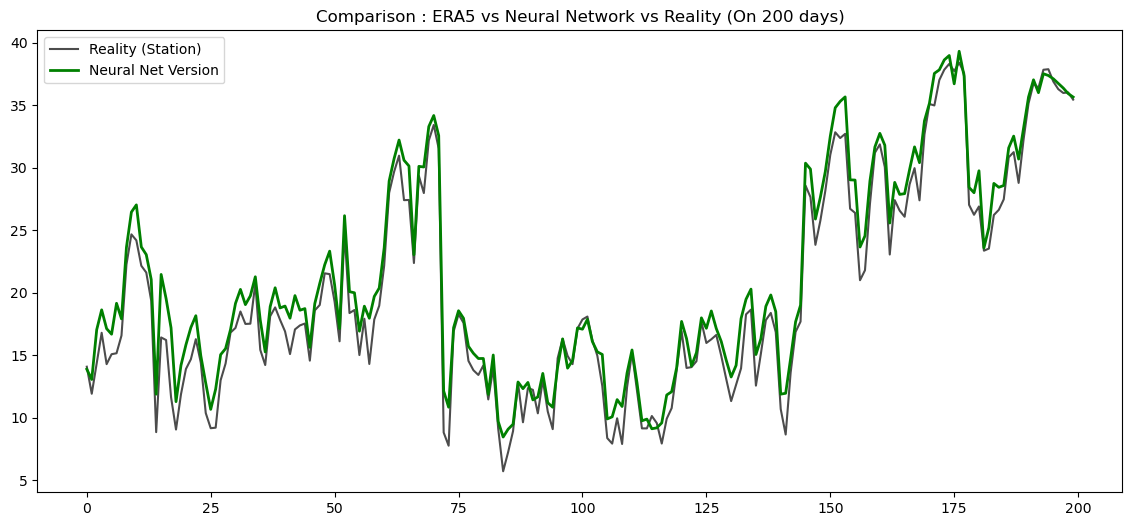

In [33]:
plt.figure(figsize=(14, 6))
num_days = 200
plt.plot(true[:num_days], label='Reality (Station)', color='black', alpha=0.7)
#plt.plot(X_test[:num_days, 0], label='ERA5 (Before)', color='red', linestyle='--', alpha=0.5)
plt.plot(y_pred[:num_days], label='Neural Net Version', color='green', linewidth=2)
plt.title(f'Comparison : ERA5 vs Neural Network vs Reality (On {num_days} days)')
plt.legend()
plt.show()

## Fourth method : SAX

In [34]:
# ==========================================
# CONFIGURATION
# ==========================================
# Chemins à adapter selon votre structure de dossiers
main_data_folder = "data/"
gadm_filepath = main_data_folder + "gadm_410_europe.gpkg"
eca_tx_datafolder = main_data_folder + "ECA_blend_tx/"
stations_filepath = eca_tx_datafolder + "stations.txt"
era5_data_folder = main_data_folder + "derived-era5-land-daily-statistics/"

# Paramètres SAX
SAX_WINDOW = 7      # Regarder les 7 derniers jours
SAX_ALPHABET = 3    # 3 niveaux (Bas, Moyen, Haut) pour simplifier

# ==========================================
# 1. FONCTIONS UTILITAIRES (SAX & GEO)
# ==========================================

def dms_to_decimal(dms_str):
    """Convertit les coordonnées DMS en décimal."""
    dms_str = dms_str.strip()
    sign = 1 if dms_str[0] == '+' else -1
    dms_str = dms_str[1:]
    parts = dms_str.split(':')
    return sign * (float(parts[0]) + float(parts[1])/60 + float(parts[2])/3600)

def compute_sax_encoding(series, window_size=7, alphabet_size=3):
    """
    Calcule un code entier unique représentant la forme (SAX) de la fenêtre glissante.
    """
    # Points de coupure pour une distribution normale (Gaussian breakpoints)
    breakpoints = stats.norm.ppf(np.linspace(0, 1, alphabet_size + 1)[1:-1])
    
    sax_codes = []
    series_values = series.values
    
    # On va calculer ça vectoriellement ou par boucle optimisée serait mieux, 
    # mais une boucle simple est plus lisible pour le hackathon.
    for i in range(len(series_values)):
        if i < window_size:
            sax_codes.append(0) # Pas assez d'historique
            continue
            
        # Fenêtre
        window = series_values[i-window_size:i]
        
        # Z-Normalize
        if np.std(window) < 1e-6:
            norm_window = np.zeros_like(window)
        else:
            norm_window = (window - np.mean(window)) / np.std(window)
            
        # Pour simplifier : on réduit la fenêtre à 3 segments moyens (PAA)
        word_len = 3
        segment_size = window_size // word_len
        if segment_size < 1: segment_size = 1
        
        paa = []
        for j in range(word_len):
            # Gérer les indices de fin pour ne pas dépasser
            start = j * segment_size
            end = (j + 1) * segment_size if j < word_len - 1 else len(window)
            paa.append(np.mean(norm_window[start:end]))
            
        # Discrétisation en entier unique (Hash)
        # Ex: Mot "0, 2, 1" (Bas, Haut, Moyen) -> 0*9 + 2*3 + 1 = 7
        code = 0
        for val in paa:
            # Trouver dans quel intervalle tombe la valeur
            symbol = np.sum(val > breakpoints)
            code = code * alphabet_size + symbol
            
        sax_codes.append(code)
        
    return np.array(sax_codes)

# ==========================================
# 2. CHARGEMENT ET PREPARATION DES DONNEES
# ==========================================

print("1. Chargement des données géographiques et ERA5...")

# 1. Charger ERA5 (Lazy loading)
# On suppose que tous les fichiers sont là
filepaths = [os.path.join(era5_data_folder, f) for f in os.listdir(era5_data_folder) if f.endswith('.nc') and '2m_temperature' in f]
ds = xr.open_mfdataset(filepaths, combine="by_coords")

# 2. Charger et Filtrer les Stations (Espagne)
gadm_gdf = gpd.read_file(gadm_filepath)
spain_gdf = gadm_gdf[(gadm_gdf.GID_0 == "ESP")&  (gadm_gdf.NAME_2 != "Madrid")].dissolve()

stations_df = pd.read_csv(stations_filepath, skiprows=17, skipinitialspace=True)
stations_df['LAT_decimal'] = stations_df['LAT'].apply(dms_to_decimal)
stations_df['LON_decimal'] = stations_df['LON'].apply(dms_to_decimal)
stations_gdf = gpd.GeoDataFrame(stations_df, geometry=gpd.points_from_xy(stations_df['LON_decimal'], stations_df['LAT_decimal']), crs="EPSG:4326")

stations_in_spain = stations_gdf[stations_gdf.within(spain_gdf.geometry.iloc[0])]
print(f"-> {len(stations_in_spain)} stations trouvées en Espagne.")

# ==========================================
# 3. CONSTRUCTION DU DATASET (BOUCLE PRINCIPALE)
# ==========================================

X_temp_list = [] # Température ERA5 (numérique)
X_sax_list = []  # Code SAX (catégoriel)
y_list = []      # Target Station

start_date = pd.Timestamp("2020-01-01")
end_date = pd.Timestamp("2023-12-31")

print("2. Construction du dataset (Extraction + SAX)...")

for idx, station in tqdm(stations_in_spain.iterrows(), total=len(stations_in_spain)):
    try:
        # A. Charger Station
        staid = station['STAID']
        fpath = eca_tx_datafolder + f"TX_STAID{staid:06d}.txt"
        if not os.path.exists(fpath): continue
            
        df_s = pd.read_csv(fpath, skiprows=20, skipinitialspace=True)
        df_s = df_s[df_s['Q_TX'] == 0] # Qualité valide uniquement
        df_s['DATE'] = pd.to_datetime(df_s['DATE'], format='%Y%m%d')
        df_s = df_s.set_index('DATE').sort_index()
        df_s = df_s.loc[(df_s.index >= start_date) & (df_s.index <= end_date)]
        
        if len(df_s) < 100: continue
        
        station_series = df_s['TX'] / 10.0 # Target
        station_series.name = 'Station_TX'
        
        # B. Charger ERA5 correspondant
        lat_s, lon_s = station.geometry.y, station.geometry.x
        era5_point = ds['t2m'].sel(latitude=lat_s, longitude=lon_s, method="nearest")
        era5_series = era5_point.to_series() - 273.15 # Input Temp
        era5_series.name = 'ERA5_TX'
        
        # C. Calculer SAX sur ERA5 (Feature Engineering)
        # On calcule le SAX sur toute la série ERA5 disponible pour ne pas avoir de trous au début
        sax_values = compute_sax_encoding(era5_series, window_size=SAX_WINDOW, alphabet_size=SAX_ALPHABET)
        sax_series = pd.Series(sax_values, index=era5_series.index, name='ERA5_SAX')
        
        # D. Fusionner
        merged = pd.concat([station_series, era5_series, sax_series], axis=1).dropna()
        
        if len(merged) == 0: continue

        # E. Ajouter aux listes
        X_temp_list.append(merged[['ERA5_TX']].values)
        X_sax_list.append(merged[['ERA5_SAX']].values)
        y_list.append(merged[['Station_TX']].values)
        
    except Exception as e:
        continue

# Conversion en arrays numpy
if len(X_temp_list) == 0:
    raise ValueError("Aucune donnée extraite. Vérifiez les chemins et dates.")

X_temp_all = np.vstack(X_temp_list)
X_sax_all = np.vstack(X_sax_list)
y_all = np.vstack(y_list)

print(f"\nDataset final : {len(y_all)} jours d'entraînement.")

# ==========================================
# 4. PREPARATION POUR LE RESEAU DE NEURONES
# ==========================================

# Split Train/Test (sans mélanger l'ordre temporel strict, mais ici random est ok pour généraliser spatialement)
indices = np.arange(len(y_all))
X_temp_train, X_temp_test, X_sax_train, X_sax_test, y_train, y_test = train_test_split(
    X_temp_all, X_sax_all, y_all, test_size=0.2, random_state=42
)

# Scaling de la température (Important !)
scaler = StandardScaler()
X_temp_train_scaled = scaler.fit_transform(X_temp_train)
X_temp_test_scaled = scaler.transform(X_temp_test)

# Pour SAX : On n'a pas besoin de scaler car ça va aller dans une couche d'Embedding
# Mais on s'assure que ce sont des entiers
X_sax_train = X_sax_train.astype(int)
X_sax_test = X_sax_test.astype(int)

# Calcul du nombre de "mots" SAX possibles pour dimensionner l'Embedding
# Max théorique = alphabet^word_len (ex: 3^3 = 27). On prend le max observé + 1 par sécurité.
vocab_size = int(np.max(X_sax_all)) + 1 

# ==========================================
# 5. MODELE HYBRIDE (INPUTS MIXTES)
# ==========================================

# A. Entrée Température (Numérique)
input_temp = Input(shape=(1,), name='input_temp')
dense_temp = Dense(32, activation='relu')(input_temp)

# B. Entrée SAX (Catégorielle -> Embedding)
input_sax = Input(shape=(1,), name='input_sax')
# Embedding : transforme l'entier SAX en vecteur dense de taille 5
embed_sax = Embedding(input_dim=vocab_size, output_dim=5)(input_sax)
flat_sax = Flatten()(embed_sax)

# C. Fusion
merged = Concatenate()([dense_temp, flat_sax])

# D. Réseau Profond
x = Dense(64, activation='relu')(merged)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)
x = Dense(16, activation='relu')(x)

# Sortie
output = Dense(1, name='output')(x)

model = Model(inputs=[input_temp, input_sax], outputs=output)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# ==========================================
# 6. ENTRAINEMENT
# ==========================================

print("3. Entraînement du modèle...")

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

history = model.fit(
    x=[X_temp_train_scaled, X_sax_train], # Liste des inputs
    y=y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=2048,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


1. Chargement des données géographiques et ERA5...
-> 900 stations trouvées en Espagne.
2. Construction du dataset (Extraction + SAX)...


100%|██████████| 900/900 [05:49<00:00,  2.58it/s]



Dataset final : 1142911 jours d'entraînement.
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_sax (InputLayer)      [(None, 1)]                  0         []                            
                                                                                                  
 input_temp (InputLayer)     [(None, 1)]                  0         []                            
                                                                                                  
 embedding (Embedding)       (None, 1, 5)                 125       ['input_sax[0][0]']           
                                                                                                  
 dense_4 (Dense)             (None, 32)                   64        ['input_temp[0][0]']          
                                               

7144/7144 [==============================] - 6s 904us/step - loss: 5.7183 - mae: 1.7416

MAE sur le Test Set : 1.7416 °C


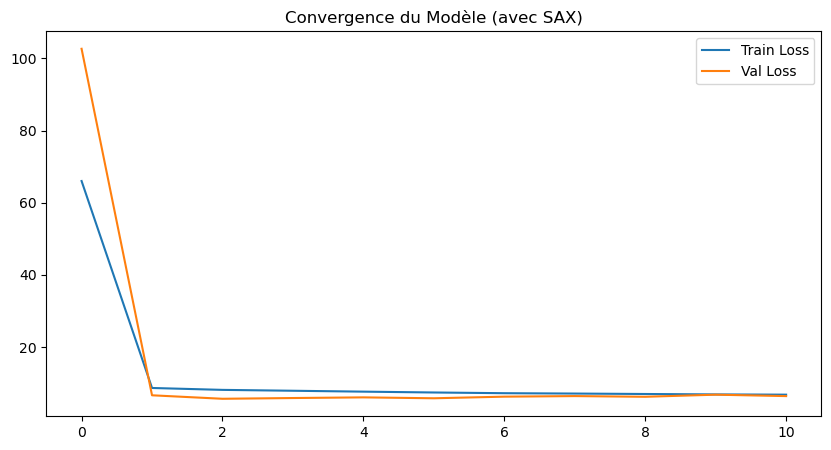

7144/7144 [==============================] - 7s 1ms/step


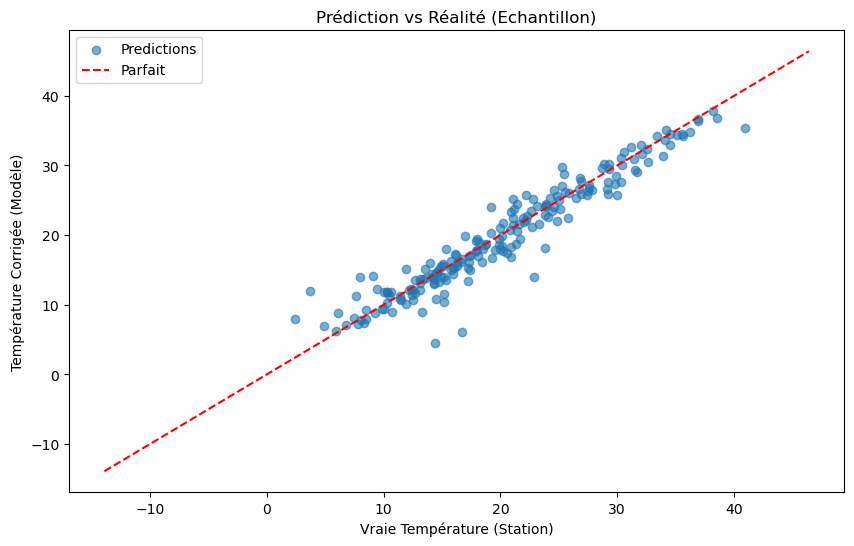

In [35]:
loss, mae = model.evaluate([X_temp_test_scaled, X_sax_test], y_test)
print(f"\nMAE sur le Test Set : {mae:.4f} °C")

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Convergence du Modèle (avec SAX)")
plt.legend()
plt.show()

# Comparaison Visuelle
preds = model.predict([X_temp_test_scaled, X_sax_test])
plt.figure(figsize=(10, 6))
plt.scatter(y_test[:200], preds[:200], alpha=0.6, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Parfait')
plt.xlabel("Vraie Température (Station)")
plt.ylabel("Température Corrigée (Modèle)")
plt.legend()
plt.title("Prédiction vs Réalité (Echantillon)")
plt.show()

Identification des stations de Madrid...
-> 21 stations trouvées à Madrid pour le Test.
Extraction des données de test (Madrid)...


100%|██████████| 21/21 [00:08<00:00,  2.33it/s]

Calcul des prédictions sur Madrid...
188/923 [=====>........................] - ETA: 0s

923/923 [==============================] - 1s 826us/step

--- RÉSULTATS SUR MADRID ---
MAE  : 1.4258 °C
Bias  : -0.0584 °C
RMSE : 1.8474 °C


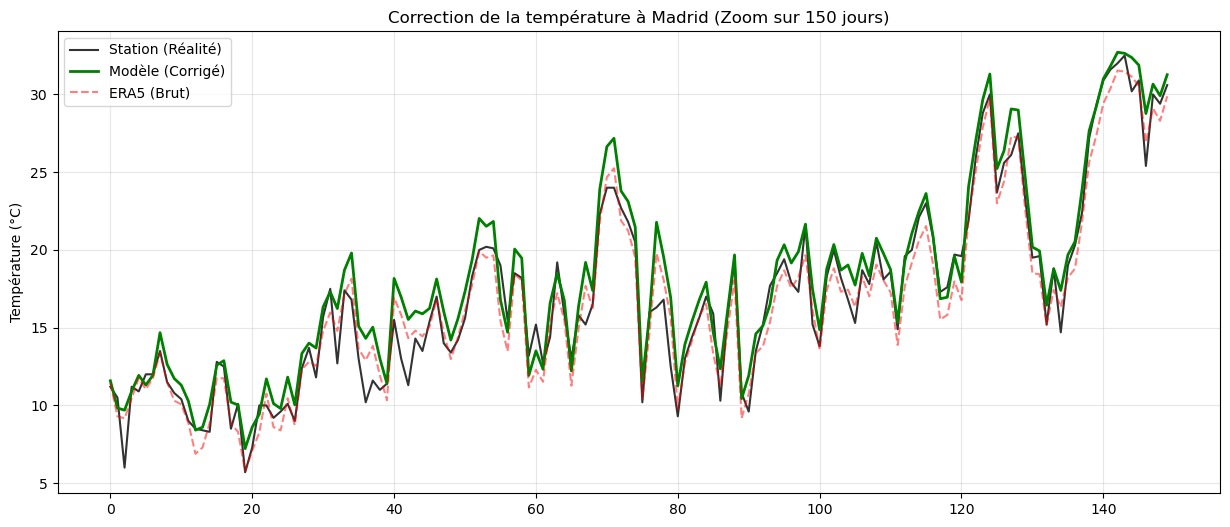

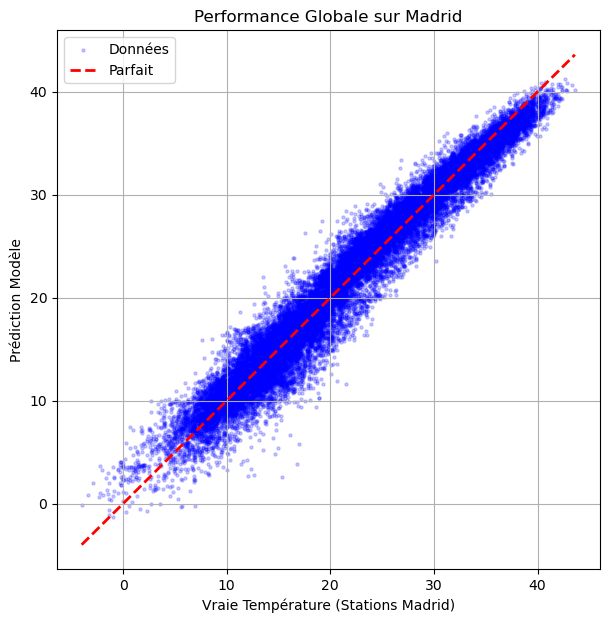

In [36]:
# ==========================================
# 1. SELECTION DES STATIONS DE MADRID
# ==========================================
print("Identification des stations de Madrid...")

# On réutilise les géométries chargées précédemment ou on les recharge
# Supposons gadm_gdf chargé. Sinon : gadm_gdf = gpd.read_file(gadm_filepath)
spain_gdf = gadm_gdf[gadm_gdf.GID_0 == "ESP"]
madrid_gdf = spain_gdf[spain_gdf.NAME_2 == "Madrid"].dissolve()

# Filtre spatial des stations
stations_in_madrid = stations_gdf[stations_gdf.within(madrid_gdf.geometry.iloc[0])]
print(f"-> {len(stations_in_madrid)} stations trouvées à Madrid pour le Test.")

# ==========================================
# 2. CREATION DU DATASET DE TEST (MADRID)
# ==========================================
X_test_temp_list = []
X_test_sax_list = []
y_test_list = []

# Période de Test (peut être la même ou une période future)
start_date_test = pd.Timestamp("2020-01-01")
end_date_test = pd.Timestamp("2023-12-31")

print("Extraction des données de test (Madrid)...")

for idx, station in tqdm(stations_in_madrid.iterrows(), total=len(stations_in_madrid)):
    try:
        # A. Station (Vérité Terrain)
        staid = station['STAID']
        fpath = eca_tx_datafolder + f"TX_STAID{staid:06d}.txt"
        
        if not os.path.exists(fpath): continue
            
        df_s = pd.read_csv(fpath, skiprows=20, skipinitialspace=True)
        df_s = df_s[df_s['Q_TX'] == 0] 
        df_s['DATE'] = pd.to_datetime(df_s['DATE'], format='%Y%m%d')
        df_s = df_s.set_index('DATE').sort_index()
        df_s = df_s.loc[(df_s.index >= start_date_test) & (df_s.index <= end_date_test)]
        
        if len(df_s) < 50: continue
        
        station_series = df_s['TX'] / 10.0
        
        # B. ERA5 (Input)
        lat_s, lon_s = station.geometry.y, station.geometry.x
        era5_point = ds['t2m'].sel(latitude=lat_s, longitude=lon_s, method="nearest")
        era5_series = era5_point.to_series() - 273.15
        
        # C. Feature SAX (Important: recalculer sur la série ERA5 locale)
        # (Assurez-vous que la fonction compute_sax_encoding est définie)
        sax_values = compute_sax_encoding(era5_series, window_size=7, alphabet_size=3)
        sax_series = pd.Series(sax_values, index=era5_series.index)
        
        # Fusion
        merged = pd.concat([station_series, era5_series, sax_series], axis=1).dropna()
        if len(merged) == 0: continue
        
        X_test_temp_list.append(merged.iloc[:, 1].values.reshape(-1, 1)) # ERA5
        X_test_sax_list.append(merged.iloc[:, 2].values.reshape(-1, 1))  # SAX
        y_test_list.append(merged.iloc[:, 0].values.reshape(-1, 1))      # Station
        
    except Exception as e:
        continue

if len(y_test_list) > 0:
    X_test_temp = np.vstack(X_test_temp_list)
    X_test_sax = np.vstack(X_test_sax_list).astype(int)
    y_test_madrid = np.vstack(y_test_list)
    
    # ==========================================
    # 3. PREDICTION & EVALUATION
    # ==========================================
    
    # Important : Utiliser le scaler ENTRAINÉ précédemment (ne pas refit !)
    X_test_temp_scaled = scaler.transform(X_test_temp)
    
    # Prédiction
    print("Calcul des prédictions sur Madrid...")
    y_pred_madrid = model.predict([X_test_temp_scaled, X_test_sax])
    
    # Metrics
    mae = mean_absolute_error(y_test_madrid, y_pred_madrid)
    bias = np.mean(y_test_madrid- y_pred_madrid)
    rmse = np.sqrt(mean_squared_error(y_test_madrid, y_pred_madrid))
    
    print(f"\n--- RÉSULTATS SUR MADRID ---")
    print(f"MAE  : {mae:.4f} °C")
    print(f"Bias  : {bias:.4f} °C")
    print(f"RMSE : {rmse:.4f} °C")
    
    # ==========================================
    # 4. VISUALISATIONS
    # ==========================================
    
    # Plot 1: Série temporelle (Zoom)
    plt.figure(figsize=(15, 6))
    subset = 150 # Affiche les 150 premiers jours
    plt.plot(y_test_madrid[:subset], label='Station (Réalité)', color='black', alpha=0.8)
    plt.plot(y_pred_madrid[:subset], label='Modèle (Corrigé)', color='green', linewidth=2)
    # Pour comparer, on affiche l'ERA5 brute (dé-scalée)
    plt.plot(X_test_temp[:subset], label='ERA5 (Brut)', color='red', linestyle='--', alpha=0.5)
    
    plt.title(f"Correction de la température à Madrid (Zoom sur {subset} jours)")
    plt.ylabel("Température (°C)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Plot 2: Scatter Plot Global
    plt.figure(figsize=(7, 7))
    plt.scatter(y_test_madrid, y_pred_madrid, alpha=0.2, s=5, c='blue', label='Données')
    plt.plot([y_test_madrid.min(), y_test_madrid.max()], 
             [y_test_madrid.min(), y_test_madrid.max()], 'r--', linewidth=2, label='Parfait')
    plt.xlabel("Vraie Température (Stations Madrid)")
    plt.ylabel("Prédiction Modèle")
    plt.title("Performance Globale sur Madrid")
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("Erreur : Aucune donnée trouvée pour Madrid sur la période demandée.")